# Deteksi Judol menggunakan Naive Baiyes, Logistic Regression

### Import

In [3]:
# 1. Data Handling
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import joblib
import re 
import unicodedata

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix



## Preprocessing

In [4]:
ds = pd.read_csv("../data_komentar_dengan_prediksi - data_komentar_dengan_prediksi(2).csv")
with open('../stopwords-id.txt', 'r', encoding='utf-8') as file:
    stopwords = [baris.strip() for baris in file.readlines()]
ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 10230 entries, 0 to 10229
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   video_id         10230 non-null  str  
 1   title            10230 non-null  str  
 2   channel_name     10230 non-null  str  
 3   tanggal          10230 non-null  str  
 4   author           10230 non-null  str  
 5   komentar         10230 non-null  str  
 6   label            10230 non-null  int64
 7   komentar_clean   10230 non-null  str  
 8   predicted_label  10230 non-null  int64
dtypes: int64(2), str(7)
memory usage: 2.6 MB


In [5]:
y = ds["label"]
def custom_tokenizer(text):
    text = str(text)
    
    # 2. Normalisasi font aneh (unicode) ke font standar biasa
    text = unicodedata.normalize('NFKD', text)
    
    # 3. Ganti semua karakter yang BUKAN huruf dan BUKAN angka dengan SPASI
    # Ini agar simbol seperti ░ atau emoji tidak bikin kata di sebelahnya menempel
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    
    # 4. Ubah ke huruf kecil semua (Case folding)
    text = text.lower()
    
    # 5. Rapikan spasi yang berlebihan dan ambil kata-katanya saja
    text = " ".join(text.split())
    
    return text


In [6]:
vectorizer = TfidfVectorizer(tokenizer=custom_tokenizer, stop_words=stopwords, max_features=5000)
x = vectorizer.fit_transform(ds["komentar_clean"])
print(vectorizer.get_feature_names_out())

c:\Documents\python_env\NLP\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Documents\python_env\NLP\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens [' ', 'a', 'b', 'c', 'd', 'e', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'w', 'y'] not in stop_words.
  warnings.warn(


[' ' '0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'a' 'b' 'c' 'd' 'e' 'f' 'g'
 'h' 'i' 'j' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r' 's' 't' 'u' 'v' 'w' 'x' 'y'
 'z']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [8]:
nb_model = MultinomialNB()
lr_model = LogisticRegression(max_iter=1000, random_state=42) 
svm_model = SVC(kernel='linear', random_state=42, probability=True)

In [9]:
# Melatih model dengan data latih
print("Sedang melatih Naive Bayes...")
nb_model.fit(X_train, y_train)

print("Sedang melatih Logistic Regression...")
lr_model.fit(X_train, y_train)

print("Sedang melatih SVM (Mungkin memakan waktu sedikit lebih lama)...")
svm_model.fit(X_train, y_train)

print("Semua model selesai dilatih!")

Sedang melatih Naive Bayes...
Sedang melatih Logistic Regression...
Sedang melatih SVM (Mungkin memakan waktu sedikit lebih lama)...
Semua model selesai dilatih!


In [10]:
from sklearn.metrics import classification_report

print("=== Hasil Evaluasi Naive Bayes ===")
print(classification_report(y_test, nb_model.predict(X_test)))

print("\n=== Hasil Evaluasi Logistic Regression ===")
print(classification_report(y_test, lr_model.predict(X_test)))

print("\n=== Hasil Evaluasi Support Vector Machine (SVM) ===")
print(classification_report(y_test, svm_model.predict(X_test)))

=== Hasil Evaluasi Naive Bayes ===
              precision    recall  f1-score   support

           0       0.81      0.97      0.89      1168
           1       0.95      0.70      0.81       878

    accuracy                           0.86      2046
   macro avg       0.88      0.84      0.85      2046
weighted avg       0.87      0.86      0.85      2046


=== Hasil Evaluasi Logistic Regression ===
              precision    recall  f1-score   support

           0       0.86      0.95      0.91      1168
           1       0.93      0.80      0.86       878

    accuracy                           0.89      2046
   macro avg       0.90      0.88      0.88      2046
weighted avg       0.89      0.89      0.89      2046


=== Hasil Evaluasi Support Vector Machine (SVM) ===
              precision    recall  f1-score   support

           0       0.83      0.97      0.90      1168
           1       0.95      0.74      0.83       878

    accuracy                           0.87      2

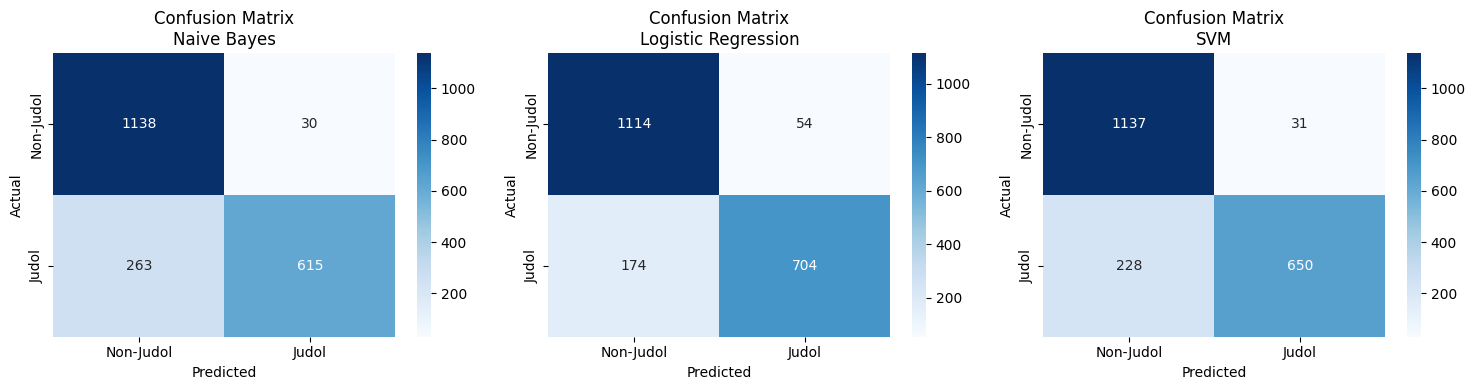

In [11]:
models = {
    "Naive Bayes": nb_model,
    "Logistic Regression": lr_model,
    "SVM": svm_model
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Judol', 'Judol'],
                yticklabels=['Non-Judol', 'Judol'])
    ax.set_title(f'Confusion Matrix\n{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

In [12]:
joblib.dump(nb_model, "NaiveBayes_pkl")
joblib.dump(lr_model, "Logistic_pkl")
joblib.dump(svm_model, "SuppVecMachine_pkl")
joblib.dump(vectorizer, "vectorizer_pkl")

['vectorizer_pkl']